In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset, WeightedRandomSampler
import torchvision.transforms as transforms
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# setup and path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_dir = '/teamspace/studios/this_studio/data'
train_lenses_dir = os.path.join(base_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(base_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(base_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(base_dir, 'test_nonlenses')
model_save_path = '/teamspace/studios/this_studio/best_lens_attention_model.pth'

Using device: cuda


In [ ]:
# dataset and augmentation
class LensDataset(Dataset):
    def __init__(self, lenses_dir, nonlenses_dir, transform=None):
        self.lens_files = glob.glob(os.path.join(lenses_dir, '*.npy'))
        self.nonlens_files = glob.glob(os.path.join(nonlenses_dir, '*.npy'))
        self.files = self.lens_files + self.nonlens_files
        self.labels = [1.0] * len(self.lens_files) + [0.0] * len(self.nonlens_files)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx]).astype(np.float32)
        epsilon = 1e-9
        data = np.log10(np.clip(data, a_min=epsilon, a_max=None))
        
        # Z-score Standardization
        for c in range(data.shape[0]):
            mean_val = np.mean(data[c])
            std_val = np.std(data[c])
            if std_val > 0:
                data[c] = (data[c] - mean_val) / std_val
                
        tensor_data = torch.from_numpy(data)
        label = torch.tensor([self.labels[idx]], dtype=torch.float32)
        
        if self.transform:
            tensor_data = self.transform(tensor_data)
        return tensor_data, label

In [ ]:
# space has no "up", so rotations and flips are works
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=(0, 180))
])

# create base datasets
full_train_dataset = LensDataset(train_lenses_dir, train_nonlenses_dir, transform=train_transform)
test_dataset = LensDataset(test_lenses_dir, test_nonlenses_dir, transform=None)

# train and validation splits
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# DataLoaders
subset_labels = [full_train_dataset.labels[i] for i in train_dataset.indices]

num_lenses_in_train = sum(subset_labels)
num_nonlenses_in_train = len(subset_labels) - num_lenses_in_train

# Calculate weights
weight_lens = num_nonlenses_in_train / num_lenses_in_train
weight_nonlens = 1.0

# Assign weights
sample_weights = [weight_lens if label == 1.0 else weight_nonlens for label in subset_labels]

# Create the Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

# --- DATALOADERS ---
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 24324 | Val samples: 6081 | Test samples: 19650


In [6]:
# Atention net (architecture)
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(x_cat))

class LensAttentionNet(nn.Module):
    def __init__(self):
        super(LensAttentionNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # 32x32
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 16x16
        )
        self.attention = SpatialAttention(kernel_size=7)
        self.deep_features = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.deep_features(x)
        x = self.classifier(x)
        return x

model = LensAttentionNet().to(device)

In [7]:
# loss function, optimizer and lr scheduler
class BinaryFocalLoss(nn.Module):
    """
    Focal Loss handles extreme imbalance by down-weighting the thousands of 
    easy "non-lens" examples and focusing on the hard/rare "lens" examples.
    """
    def __init__(self, alpha=0.95, gamma=2):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha # heavily weights the positive class (lenses)
        self.gamma = gamma # focusing parameter
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss) 
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

criterion = BinaryFocalLoss(alpha=0.50, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [8]:
# train and val loop
epochs = 15
best_val_loss = float('inf')

print("\n--- Starting Training ---")
for epoch in range(epochs):
    # training
    model.train()
    running_train_loss = 0.0
    train_prog = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
    
    for inputs, labels in train_prog:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        train_prog.set_postfix({'loss': f'{loss.item():.4f}'})
        
    avg_train_loss = running_train_loss / len(train_loader)

    # validation
    model.eval()
    running_val_loss = 0.0
    val_prog = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False)
    
    with torch.no_grad():
        for inputs, labels in val_prog:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    scheduler.step(avg_val_loss)
    
    # checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_save_path)
        print(f"  -> Val loss improved! Saved model.")



--- Starting Training ---


Epoch 01 | Train Loss: 0.0509 | Val Loss: 0.0268
  -> Val loss improved! Saved model.


Epoch 02 | Train Loss: 0.0311 | Val Loss: 0.0137
  -> Val loss improved! Saved model.


Epoch 03 | Train Loss: 0.0284 | Val Loss: 0.0204


Epoch 04 | Train Loss: 0.0266 | Val Loss: 0.0270


...

Epoch 11 | Train Loss: 0.0186 | Val Loss: 0.0146


Epoch 12 | Train Loss: 0.0178 | Val Loss: 0.0203


Epoch 13 | Train Loss: 0.0183 | Val Loss: 0.0117
  -> Val loss improved! Saved model.


Epoch 14 | Train Loss: 0.0168 | Val Loss: 0.0097
  -> Val loss improved! Saved model.


Epoch 15 | Train Loss: 0.0163 | Val Loss: 0.0216



--- Starting Evaluation ---
Loaded best weights for testing.


Evaluating: 100%|██████████| 615/615 [00:08<00:00, 75.94it/s]



--- Per-Class Performance Report ---
                      precision    recall  f1-score   support

Non-Lenses (Class 0)       1.00      0.98      0.99     19455
    Lenses (Class 1)       0.31      0.89      0.46       195

            accuracy                           0.98     19650
           macro avg       0.66      0.94      0.73     19650
        weighted avg       0.99      0.98      0.98     19650

Test AUC Score: 0.9890


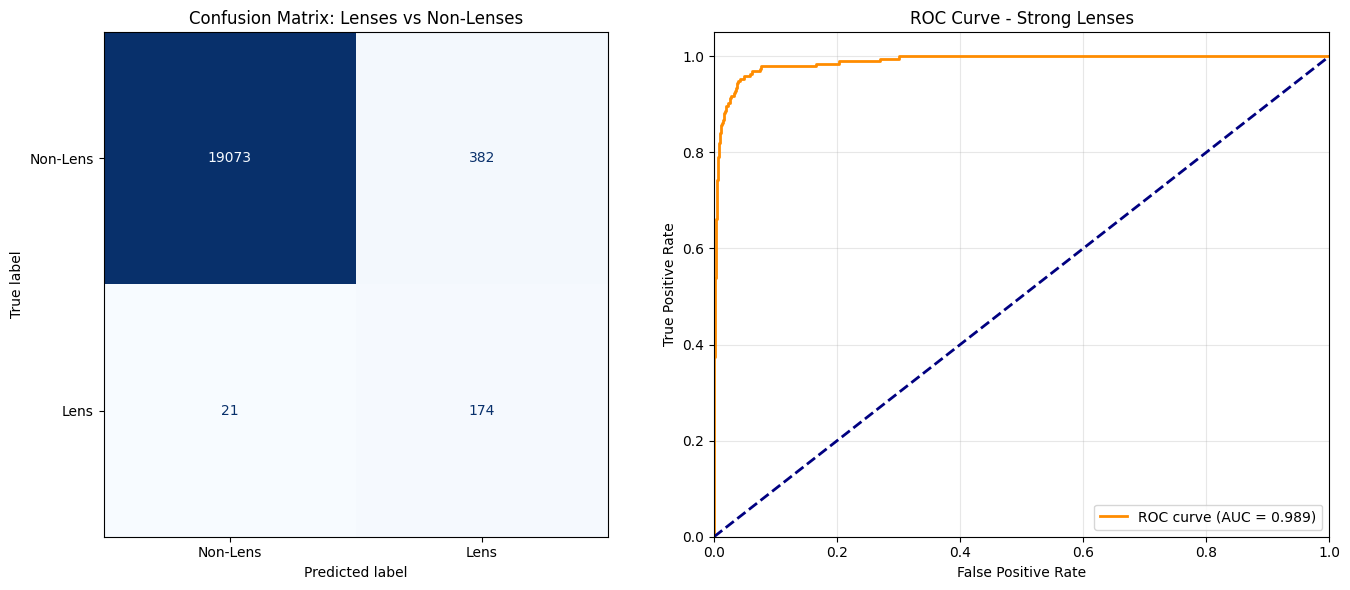

In [9]:
# eval and metrics
print("\n--- Starting Evaluation ---")
try:
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    print("Loaded best weights for testing.")
except FileNotFoundError:
    print("Error: Model weights not found. Ensure training completed.")

model.eval()
all_labels, all_preds = [], []
test_prog = tqdm(test_loader, desc='Evaluating')

with torch.no_grad():
    for inputs, labels in test_prog:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model(inputs)
        probs = torch.sigmoid(logits)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(probs.cpu().numpy())

y_true = np.array(all_labels).flatten()
y_scores = np.array(all_preds).flatten()
y_pred = (y_scores >= 0.5).astype(int)

print("\n--- Per-Class Performance Report ---")
target_names = ['Non-Lenses (Class 0)', 'Lenses (Class 1)']
print(classification_report(y_true, y_pred, target_names=target_names))

# ROC curve & AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print(f"Test AUC Score: {roc_auc:.4f}")

# plotting Confusion Matrix & ROC Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Lens', 'Lens'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix: Lenses vs Non-Lenses')

# ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Strong Lenses')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
print("--- Phase 1: Identifying Hard Examples ---")

# load the best model weights
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# create a non-shuffled loader for the training data to track indices
mining_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)

all_errors = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(mining_loader, desc="Mining Training Data"):
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model(inputs)
        probs = torch.sigmoid(logits)
        
        # calculate absolute error: |Prediction - Actual Label|
        # where high error means the model was very confident but completely wrong
        errors = torch.abs(probs - labels).cpu().numpy().flatten()
        all_errors.extend(errors)
        all_labels.extend(labels.cpu().numpy().flatten())

all_errors = np.array(all_errors)
all_labels = np.array(all_labels)

# separate the indices
# get indices of all actual lenses in the training set
lens_indices = np.where(all_labels == 1.0)[0]

# get indices of non-lenses
non_lens_indices = np.where(all_labels == 0.0)[0]

# sort non-lenses by error (highest error first)
non_lens_errors = all_errors[non_lens_indices]
sorted_non_lens_positions = np.argsort(non_lens_errors)[::-1] # Descending order
sorted_non_lens_indices = non_lens_indices[sorted_non_lens_positions]

# create the hard dataset
# taking the 1,500 absolute hardest non-lenses (False Positives)
# and combine them with ALL the lenses (to maintain balance and prevent forgetting)
num_hard_negatives = 1500
hard_negative_indices = sorted_non_lens_indices[:num_hard_negatives]

# combine indices
bootcamp_indices = np.concatenate([lens_indices, hard_negative_indices])

# create a new PyTorch Subset using these specific indices
bootcamp_dataset = Subset(train_dataset, bootcamp_indices)

# create the new fine-tuning DataLoader
bootcamp_loader = DataLoader(bootcamp_dataset, batch_size=32, shuffle=True, num_workers=2)

print(f"\nMined Dataset Created: {len(lens_indices)} Lenses + {num_hard_negatives} Hard Non-Lenses.")
print(f"Total Bootcamp Samples: {len(bootcamp_dataset)}")

--- Phase 1: Identifying Hard Examples ---


Mining Training Data:   1%|          | 6/761 [00:00<00:26, 28.28it/s]

Mining Training Data: 100%|██████████| 761/761 [00:20<00:00, 37.64it/s]


Mined Dataset Created: 1381 Lenses + 1500 Hard Non-Lenses.
Total Bootcamp Samples: 2881


In [66]:
print("\n--- Phase 2: Fine-Tuning Bootcamp ---")

# load the best model weights
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# lower learning rate
fine_tune_optimizer = torch.optim.Adam(model.parameters(), lr=7e-7, weight_decay=1e-4)

bootcamp_epochs = 4

for epoch in range(bootcamp_epochs):
    model.train()
    running_loss = 0.0
    
    prog_bar = tqdm(bootcamp_loader, desc=f"Bootcamp Epoch {epoch+1}/{bootcamp_epochs}", leave=False)
    
    for inputs, labels in prog_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        fine_tune_optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        fine_tune_optimizer.step()
        
        running_loss += loss.item()
        prog_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    print(f"Bootcamp Epoch {epoch+1} | Loss: {running_loss/len(bootcamp_loader):.4f}")

# save the newly fine-tuned model
finetuned_model_path = '/teamspace/studios/this_studio/finetuned_lens_model.pth'
torch.save(model.state_dict(), finetuned_model_path)
print(f"\nFine-tuning complete. Model saved to {finetuned_model_path}")


--- Phase 2: Fine-Tuning Bootcamp ---


Bootcamp Epoch 1/4:   1%|          | 1/91 [00:00<00:13,  6.78it/s, loss=0.0669]

Bootcamp Epoch 1 | Loss: 0.0774


Bootcamp Epoch 2 | Loss: 0.0767


Bootcamp Epoch 3 | Loss: 0.0752


Bootcamp Epoch 4 | Loss: 0.0721

Fine-tuning complete. Model saved to /teamspace/studios/this_studio/finetuned_lens_model.pth



--- Starting Evaluation ---
Loaded best weights for testing.


Evaluating:   1%|▏         | 9/615 [00:00<00:13, 45.08it/s]

Evaluating: 100%|██████████| 615/615 [00:07<00:00, 76.91it/s]



--- Per-Class Performance Report ---
                      precision    recall  f1-score   support

Non-Lenses (Class 0)       1.00      0.98      0.99     19455
    Lenses (Class 1)       0.35      0.88      0.50       195

            accuracy                           0.98     19650
           macro avg       0.67      0.93      0.74     19650
        weighted avg       0.99      0.98      0.99     19650

Test AUC Score: 0.9894


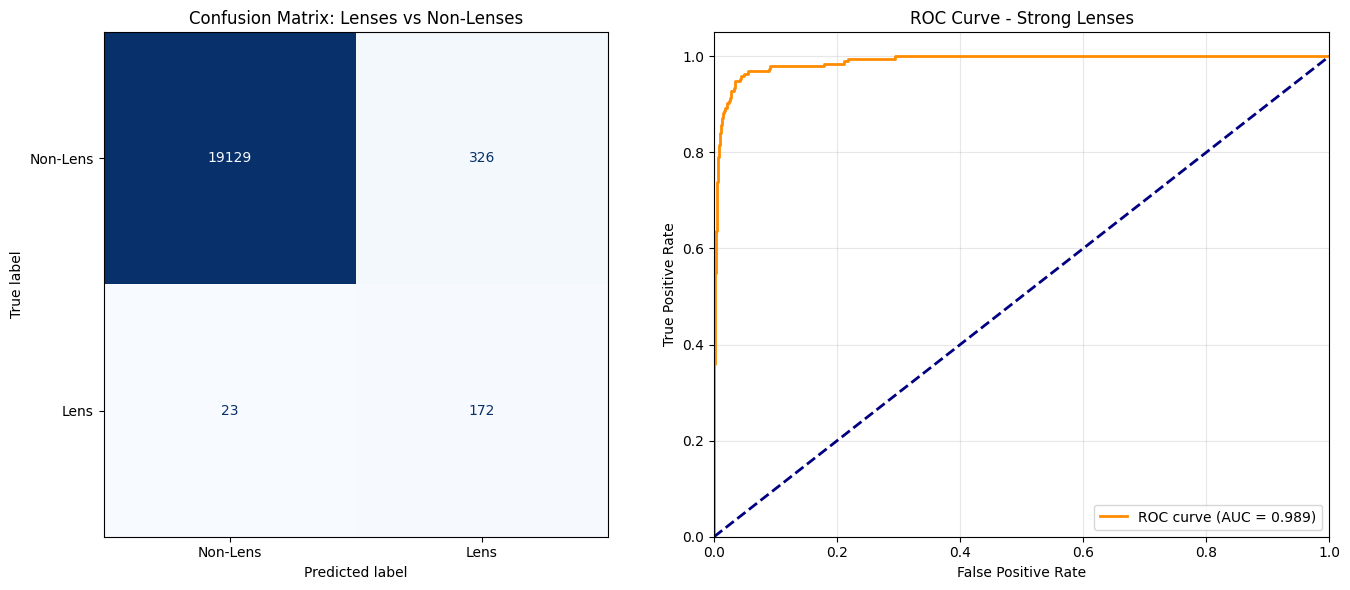

In [67]:
# eval and metrics
print("\n--- Starting Evaluation ---")
try:
    model.load_state_dict(torch.load(finetuned_model_path, map_location=device))
    print("Loaded best weights for testing.")
except FileNotFoundError:
    print("Error: Model weights not found. Ensure training completed.")

model.eval()
all_labels, all_preds = [], []
test_prog = tqdm(test_loader, desc='Evaluating')

with torch.no_grad():
    for inputs, labels in test_prog:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model(inputs)
        probs = torch.sigmoid(logits)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(probs.cpu().numpy())

y_true = np.array(all_labels).flatten()
y_scores = np.array(all_preds).flatten()
y_pred = (y_scores >= 0.5).astype(int)

print("\n--- Per-Class Performance Report ---")
target_names = ['Non-Lenses (Class 0)', 'Lenses (Class 1)']
print(classification_report(y_true, y_pred, target_names=target_names))

# ROC curve & AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print(f"Test AUC Score: {roc_auc:.4f}")

# plotting Confusion Matrix & ROC Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Lens', 'Lens'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix: Lenses vs Non-Lenses')

# ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Strong Lenses')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


--- Starting Evaluation with Test-Time Augmentation (TTA) ---


Evaluating with TTA:   3%|▎         | 17/615 [00:00<00:10, 56.97it/s]

Evaluating with TTA: 100%|██████████| 615/615 [00:08<00:00, 75.47it/s]



--- TTA Per-Class Performance Report ---
                      precision    recall  f1-score   support

Non-Lenses (Class 0)       1.00      0.98      0.99     19455
    Lenses (Class 1)       0.35      0.88      0.50       195

            accuracy                           0.98     19650
           macro avg       0.67      0.93      0.75     19650
        weighted avg       0.99      0.98      0.99     19650

Test AUC Score (with TTA): 0.9895


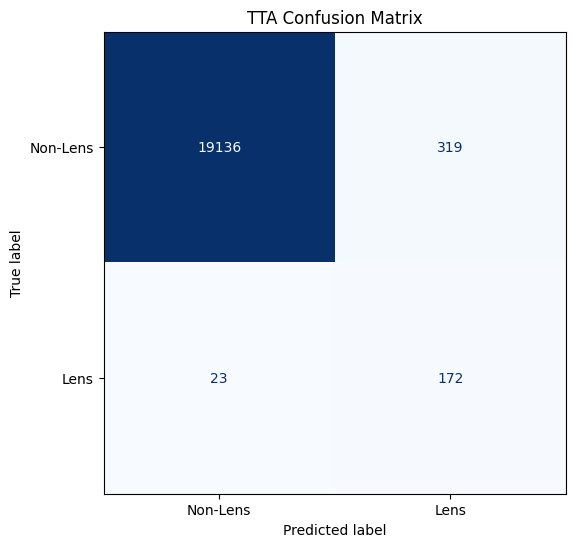

In [68]:
print("\n--- Starting Evaluation with Test-Time Augmentation (TTA) ---")

model.load_state_dict(torch.load(finetuned_model_path, map_location=device))
model.eval()

all_labels = []
all_preds_tta = []

test_prog = tqdm(test_loader, desc='Evaluating with TTA')

with torch.no_grad():
    for inputs, labels in test_prog:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # original Image
        logits_orig = model(inputs)
        probs_orig = torch.sigmoid(logits_orig)
        
        # horizontal Flip
        inputs_hflip = torch.flip(inputs, dims=[3])
        logits_hflip = model(inputs_hflip)
        probs_hflip = torch.sigmoid(logits_hflip)
        
        # 3vertical Flip
        inputs_vflip = torch.flip(inputs, dims=[2])
        logits_vflip = model(inputs_vflip)
        probs_vflip = torch.sigmoid(logits_vflip)
        
        # rotate 90 Degrees
        inputs_rot = torch.rot90(inputs, k=1, dims=[2, 3])
        logits_rot = model(inputs_rot)
        probs_rot = torch.sigmoid(logits_rot)
        
        # averaging the probabilities as this smooths out borderline uncertainties
        avg_probs = (probs_orig + probs_hflip + probs_vflip + probs_rot) / 4.0
        
        all_labels.extend(labels.cpu().numpy())
        all_preds_tta.extend(avg_probs.cpu().numpy())

# convert to arrays
y_true = np.array(all_labels).flatten()
y_scores_tta = np.array(all_preds_tta).flatten()
y_pred_tta = (y_scores_tta >= 0.5).astype(int)

print("\n--- TTA Per-Class Performance Report ---")
target_names = ['Non-Lenses (Class 0)', 'Lenses (Class 1)']
print(classification_report(y_true, y_pred_tta, target_names=target_names))

# ROC and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores_tta)
roc_auc = auc(fpr, tpr)
print(f"Test AUC Score (with TTA): {roc_auc:.4f}")

# plotting Confusion Matrix
cm = confusion_matrix(y_true, y_pred_tta)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Lens', 'Lens'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title('TTA Confusion Matrix')
plt.show()

### Note:
In machine learning, optimizing a model is rarely as simple as making every metric go up at once. Instead, it behaves much like an economic transaction known as the Precision-Recall Tradeoff: to gain in one area, you usually have to pay a cost in another.

In the context of hunting for rare gravitational lenses, we are constantly navigating the exchange rate between two competing goals:

- Precision (Reducing False Alarms): If we tune the model to be extremely strict to avoid false positives, we save astrophysicists time, but we pay the cost of missing borderline lenses.

- Recall (Maximizing Discoveries): Conversely, if we cast a wide net to ensure we don't accidentally throw away a valuable discovery, we pay the price of manually sorting through hundreds of empty background images.

Ultimately, the task boils down to finding the model that offers the best "price" for the specific scientific goal we want to achieve.